# ISOT Fake News Dataset 



## 1. EDA

This notebook focuses on a detailed exploratory data analysis (EDA) of the ISOT Fake News dataset.
Goals:
- Understand dataset structure and class balance.
- Inspect missing values and duplicates.
- Explore text length distributions and vocabulary patterns.
- Review sample records.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re
import nltk

import nltk
for resource in ['punkt_tab', 'punkt', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split


sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=sns.color_palette("Set2"))

In [52]:
true_df = pd.read_csv(r"C:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\True.csv")
fake_df = pd.read_csv(r"C:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\Fake.csv")

true_df['label'] = 'real'
fake_df['label'] = 'fake'

df = pd.concat([true_df, fake_df], ignore_index=True)
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",real
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",real
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",real
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",real
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",real


## Dataset overview
We check the shape, column names, and a quick preview.

In [3]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.sample(5, random_state=42)

Shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
22216,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",fake
27917,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",fake
25007,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",fake
1377,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",real
32476,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",fake


## Data types and missing values

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  str  
dtypes: str(5)
memory usage: 1.7 MB


In [5]:
df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

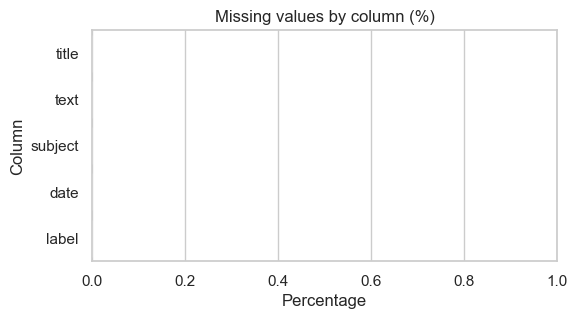

In [6]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(6, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title('Missing values by column (%)')
plt.xlabel('Percentage')
plt.ylabel('Column')
plt.xlim(0, max(1, missing_pct.max()))
plt.show()

**Interprétation.** Ce graphe montre le pourcentage de valeurs manquantes par colonne.
Si toutes les barres sont proches de 0, les données sont complètes.
Des valeurs élevées indiqueraient des colonnes à nettoyer ou à éliminer.

## Duplicates

In [7]:
duplicates = df.duplicated().sum()
print('Number of duplicates:', duplicates)

Number of duplicates: 209


## Class balance

label
fake    23481
real    21417
Name: count, dtype: int64


label
fake    23481
real    21417
Name: count, dtype: int64


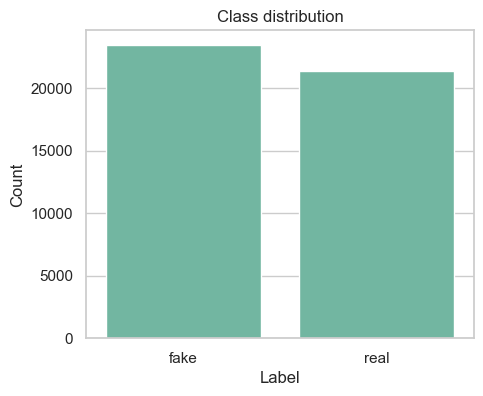

In [8]:

class_counts = df['label'].value_counts()
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

**Interprétation.** La barre indique le nombre d’articles par classe.
On vérifie ici si le dataset est équilibré ou non.
Un déséquilibre fort nécessite des précautions lors de l’entraînement.

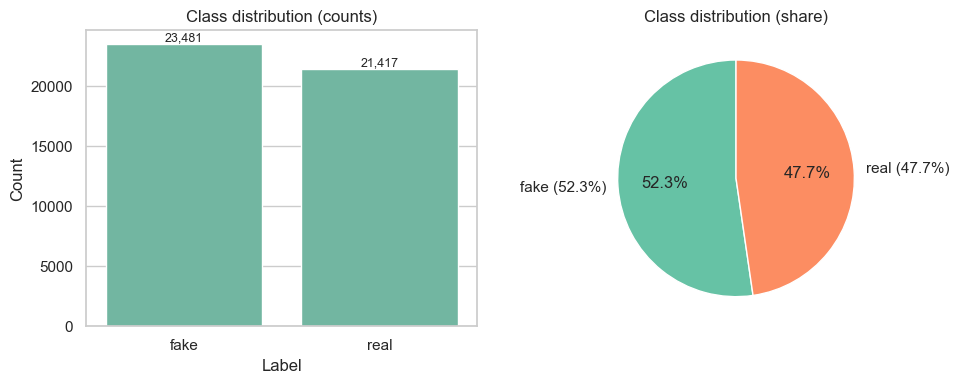

In [9]:
class_counts_pct = (class_counts / class_counts.sum() * 100).round(2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0])
axes[0].set_title('Class distribution (counts)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)
axes[1].pie(
    class_counts.values,
    labels=[f"{lbl} ({pct}%)" for lbl, pct in zip(class_counts.index, class_counts_pct)],
    autopct='%1.1f%%',
    startangle=90
 )
axes[1].set_title('Class distribution (share)')
plt.tight_layout()
plt.show()

**Interprétation.** Le camembert met en évidence la part relative de chaque classe.
Une répartition proche de 50/50 est idéale pour les modèles.
Si une classe domine, on peut prévoir un rééquilibrage.

## Subject distribution
Cette section analyse les thèmes (colonne subject) et leur répartition par classe.

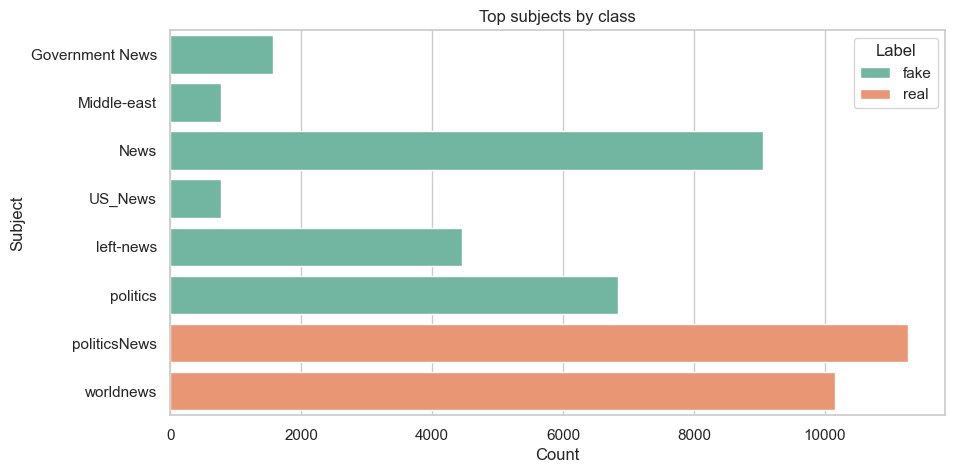

In [10]:
if 'subject' in df.columns:
    subject_counts = (
        df.groupby(['label', 'subject'])
        .size()
        .reset_index(name='count')
    )
    top_subjects = (
        subject_counts.groupby('subject')['count']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )
    subject_counts = subject_counts[subject_counts['subject'].isin(top_subjects)]
    plt.figure(figsize=(10, 5))
    sns.barplot(data=subject_counts, x='count', y='subject', hue='label')
    plt.title('Top subjects by class')
    plt.xlabel('Count')
    plt.ylabel('Subject')
    plt.legend(title='Label')
    plt.show()
else:
    print('Column subject not found in dataset.')

**Interprétation.** Ce graphe compare les sujets dominants entre fake et real.
Il permet d’identifier des thèmes sur‑représentés dans une classe.
Les sujets très spécifiques peuvent devenir des indicateurs utiles.

## Text length statistics

In [11]:
df['text_len_chars'] = df['text'].astype(str).str.len()
df['text_len_words'] = df['text'].astype(str).str.split().str.len()

df[['text_len_chars', 'text_len_words']].describe()

,text_len_chars,text_len_words
count,44898.000000,44898.000000
mean,2469.109693,405.282284
std,2171.617091,351.265595
min,1.000000,0.000000
25%,1234.000000,203.000000
50%,2186.000000,362.000000
75%,3105.000000,513.000000
max,51794.000000,8135.000000


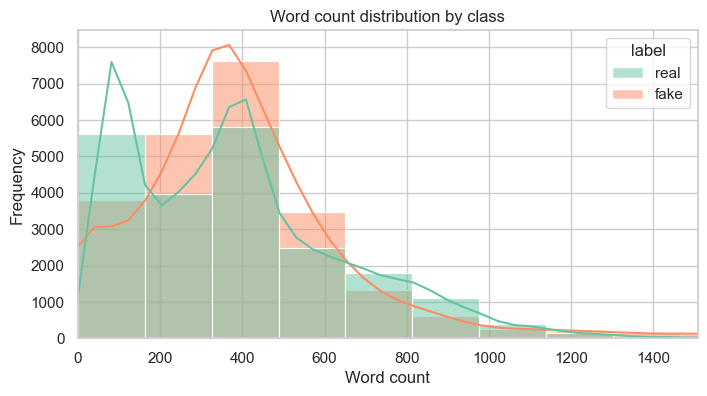

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='text_len_words', hue='label', bins=50, kde=True)
plt.title('Word count distribution by class')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.xlim(0, df['text_len_words'].quantile(0.99))
plt.show()

**Interprétation.** Ce histogramme compare la longueur des articles en mots.
On observe la dispersion et les valeurs extrêmes par classe.
Des différences de distribution peuvent aider la classification.

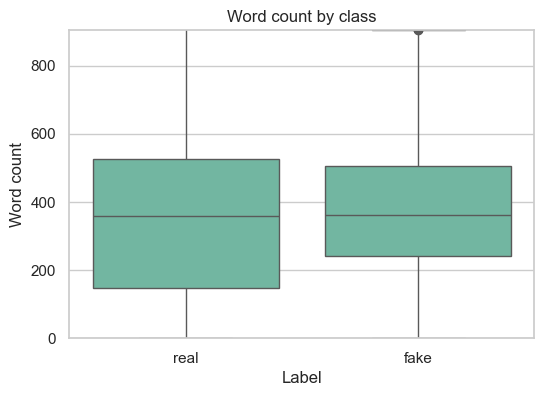

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='label', y='text_len_words')
plt.title('Word count by class')
plt.xlabel('Label')
plt.ylabel('Word count')
plt.ylim(0, df['text_len_words'].quantile(0.95))
plt.show()

**Interprétation.** Le boxplot met en évidence médiane et dispersion par classe.
Des écarts visibles suggèrent des styles d’écriture différents.
Les valeurs extrêmes sont limitées pour éviter l’effet des outliers.

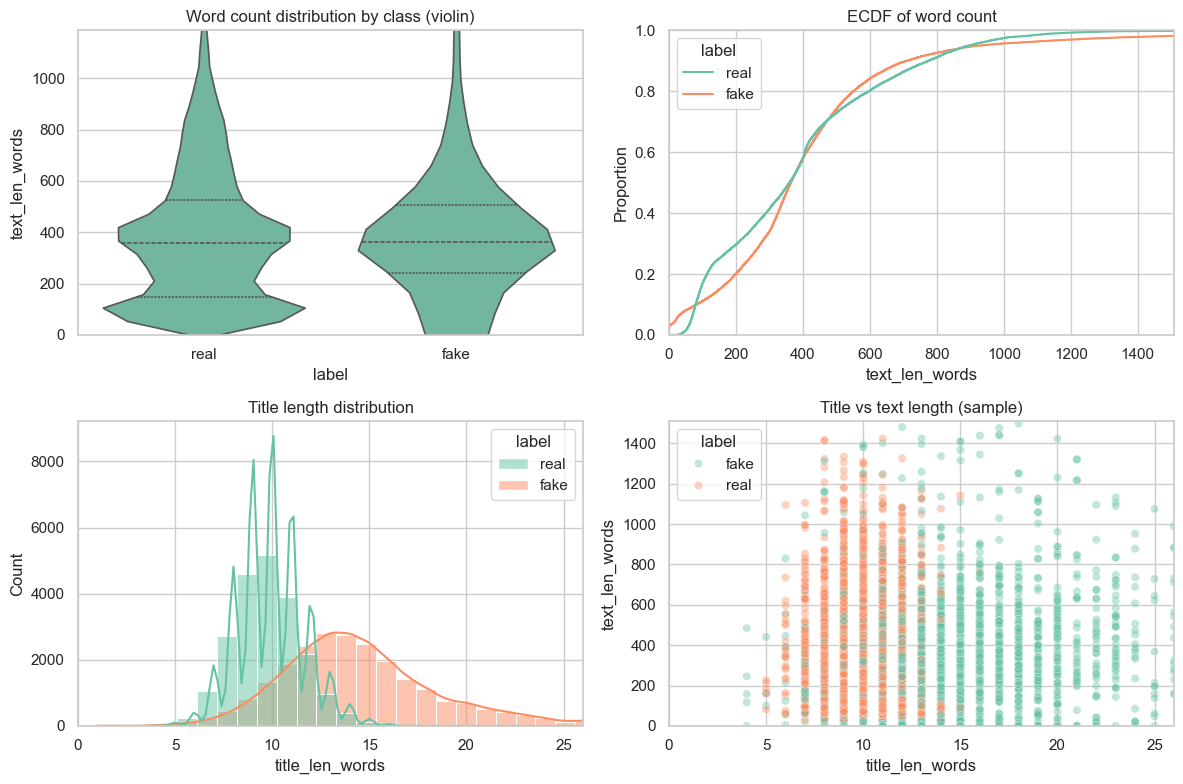

In [14]:
df['title_len_words'] = df['title'].astype(str).str.split().str.len()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.violinplot(data=df, x='label', y='text_len_words', ax=axes[0, 0], inner='quartile', cut=0)
axes[0, 0].set_ylim(0, df['text_len_words'].quantile(0.98))
axes[0, 0].set_title('Word count distribution by class (violin)')
sns.ecdfplot(data=df, x='text_len_words', hue='label', ax=axes[0, 1])
axes[0, 1].set_xlim(0, df['text_len_words'].quantile(0.99))
axes[0, 1].set_title('ECDF of word count')
sns.histplot(data=df, x='title_len_words', hue='label', bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Title length distribution')
axes[1, 0].set_xlim(0, df['title_len_words'].quantile(0.99))
sample_df = df[['title_len_words', 'text_len_words', 'label']].sample(5000, random_state=42)
sns.scatterplot(data=sample_df, x='title_len_words', y='text_len_words', hue='label', alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_ylim(0, df['text_len_words'].quantile(0.99))
axes[1, 1].set_xlim(0, df['title_len_words'].quantile(0.99))
axes[1, 1].set_title('Title vs text length (sample)')
plt.tight_layout()
plt.show()

**Interprétation.** Les violons et ECDF résument la distribution complète des longueurs.
Le graphique des titres montre la taille moyenne des headlines par classe.
Le nuage titre vs texte permet d’observer la relation entre les deux tailles.

## Title length in characters
Cette partie mesure la longueur des titres en caractères par classe.

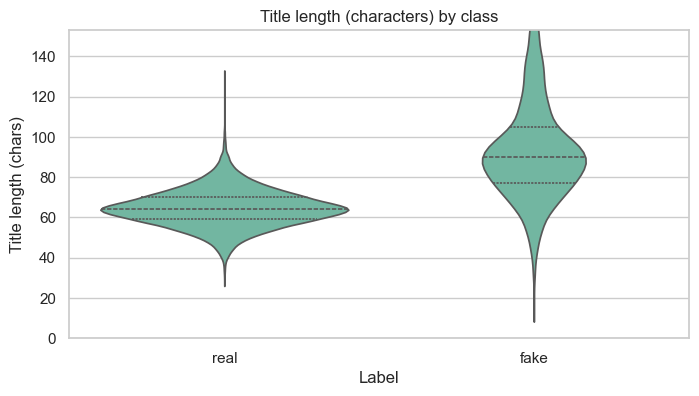

In [15]:
df['title_len_chars'] = df['title'].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='label', y='title_len_chars', inner='quartile', cut=0)
plt.title('Title length (characters) by class')
plt.xlabel('Label')
plt.ylabel('Title length (chars)')
plt.ylim(0, df['title_len_chars'].quantile(0.98))
plt.show()

**Interprétation.** Ce graphe compare la taille des titres en caractères.
Des titres plus courts ou plus longs peuvent être liés au style des articles.
Une différence nette peut aider les modèles basés sur la longueur.

## Unique words vs text length
Cette section compare la richesse lexicale et la longueur des articles.

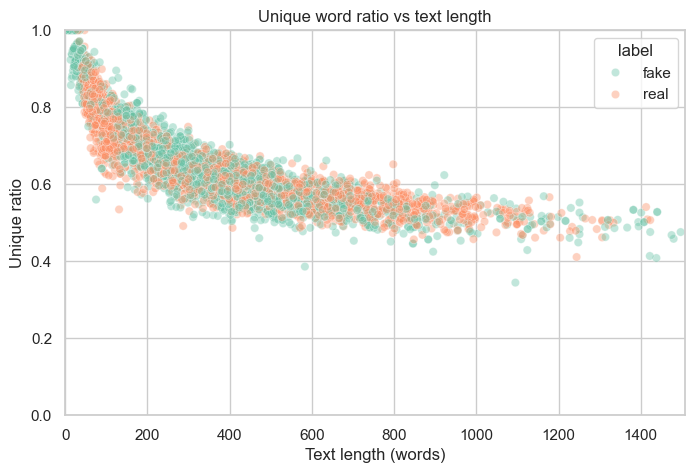

In [16]:
text_tokens = df['text'].astype(str).str.split()
df['unique_words'] = text_tokens.apply(lambda tokens: len(set(tokens)))
df['unique_ratio'] = df['unique_words'] / df['text_len_words'].replace(0, np.nan)
sample_unique = df[['text_len_words', 'unique_ratio', 'label']].sample(5000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_unique, x='text_len_words', y='unique_ratio', hue='label', alpha=0.4)
plt.title('Unique word ratio vs text length')
plt.xlabel('Text length (words)')
plt.ylabel('Unique ratio')
plt.xlim(0, df['text_len_words'].quantile(0.99))
plt.ylim(0, 1)
plt.show()

**Interprétation.** Le ratio de mots uniques mesure la richesse lexicale.
Un ratio plus faible peut indiquer des répétitions ou un vocabulaire limité.
La relation avec la longueur aide à distinguer les styles d’articles.

## Correlation heatmap
Cette carte montre les relations entre métriques numériques et la classe.

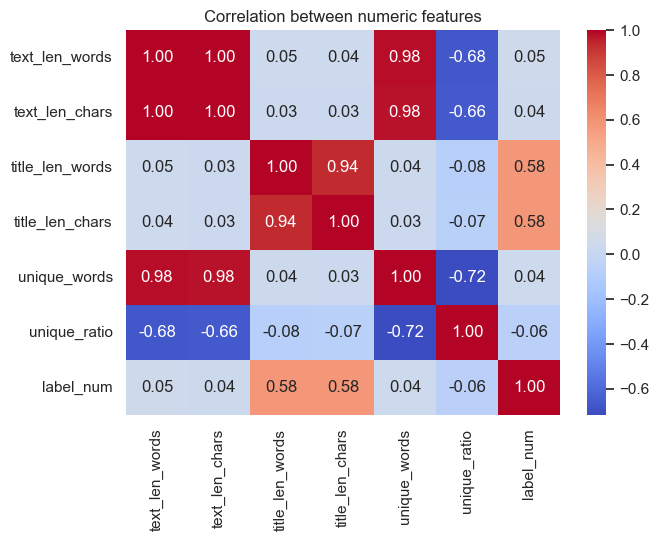

In [17]:
numeric_df = df.copy()
numeric_df['label_num'] = numeric_df['label'].map({'real': 0, 'fake': 1})
corr_cols = [
    'text_len_words',
    'text_len_chars',
    'title_len_words',
    'title_len_chars',
    'unique_words',
    'unique_ratio',
    'label_num'
]
corr_data = numeric_df[corr_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between numeric features')
plt.show()

**Interprétation.** Cette matrice met en évidence les relations entre variables numériques.
Une corrélation élevée indique que deux métriques varient ensemble.
La colonne label_num aide à repérer les features liées à la classe.

## Most frequent words (quick view)

In [18]:
sample_texts = df['text'].astype(str).sample(2000, random_state=42)
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(sample_texts)
word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': np.array(X.sum(axis=0)).flatten()
}).sort_values('count', ascending=False)
word_freq

,word,count
16,trump,6175
12,said,5933
9,president,2652
8,people,1830
13,state,1575
6,new,1437
11,reuters,1321
7,obama,1313
1,clinton,1295
2,donald,1287


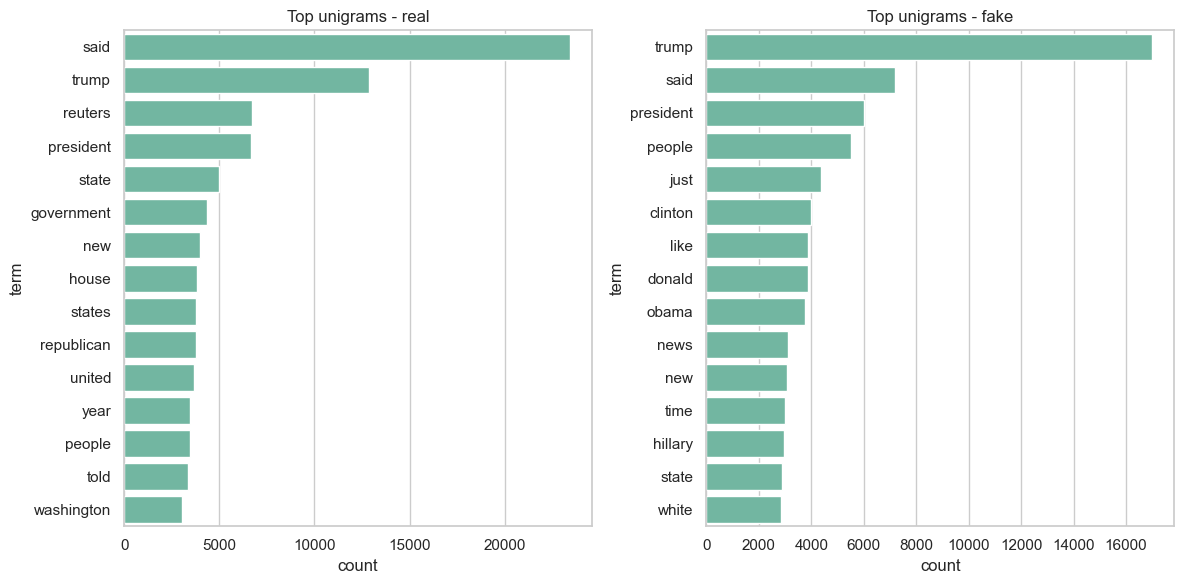

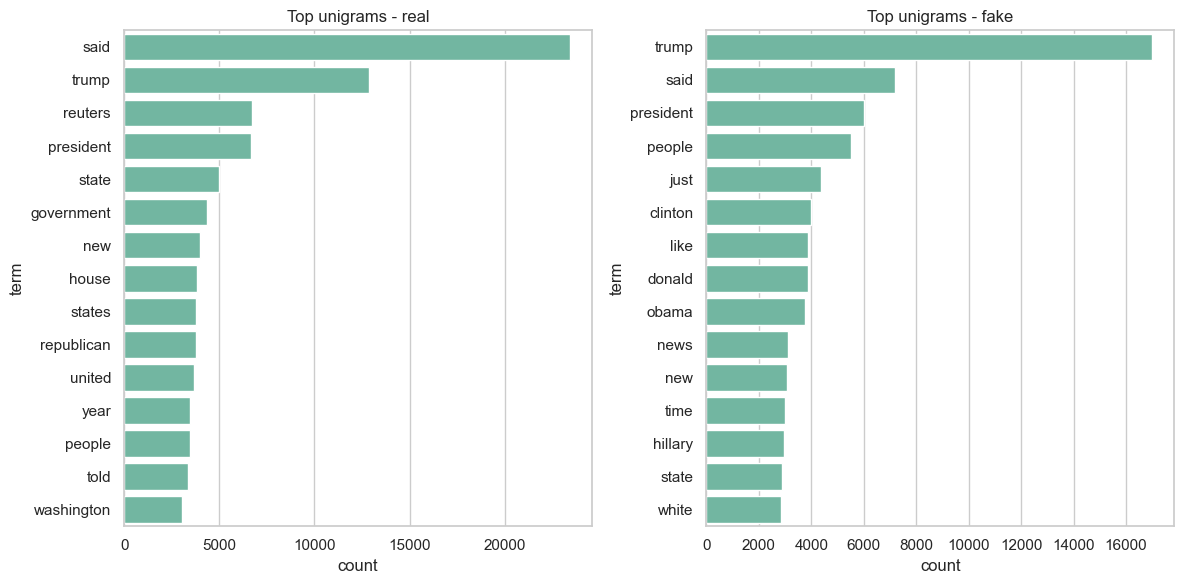

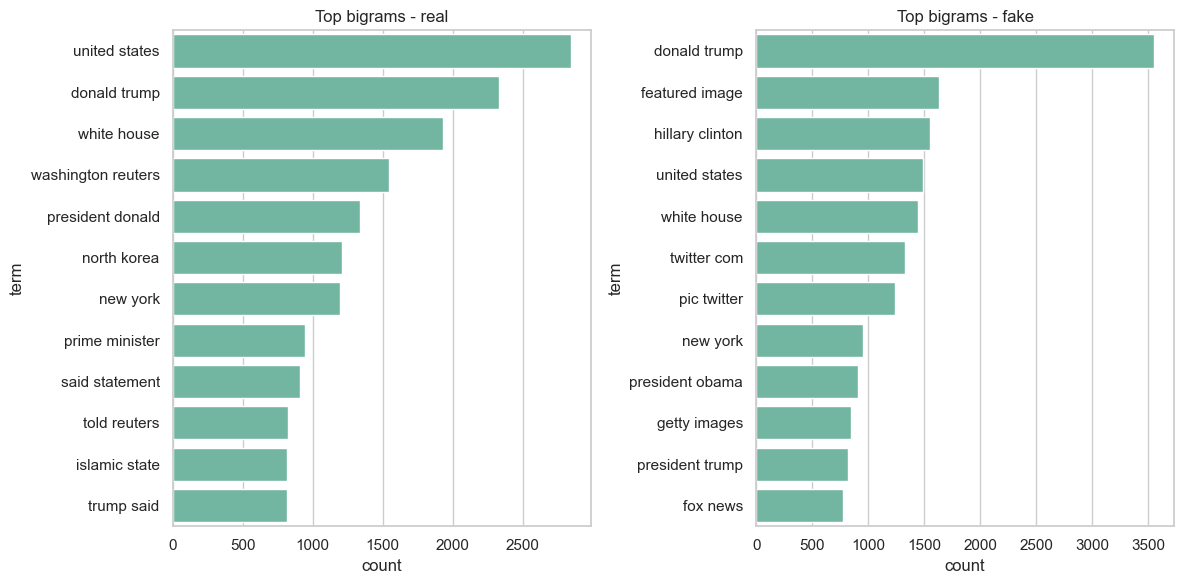

In [19]:
def get_top_terms(texts, ngram_range=(1, 1), top_n=15):
    vec = CountVectorizer(stop_words='english', max_features=5000, ngram_range=ngram_range)
    X = vec.fit_transform(texts)
    sums = np.array(X.sum(axis=0)).flatten()
    terms = vec.get_feature_names_out()
    return (
        pd.DataFrame({'term': terms, 'count': sums})
        .sort_values('count', ascending=False)
        .head(top_n)
    )

sample_real = df[df['label'] == 'real']['text'].astype(str).sample(5000, random_state=42)
sample_fake = df[df['label'] == 'fake']['text'].astype(str).sample(5000, random_state=42)

top_real = get_top_terms(sample_real, ngram_range=(1, 1), top_n=15)
top_fake = get_top_terms(sample_fake, ngram_range=(1, 1), top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(data=top_real, y='term', x='count', ax=axes[0])
axes[0].set_title('Top unigrams - real')
sns.barplot(data=top_fake, y='term', x='count', ax=axes[1])
axes[1].set_title('Top unigrams - fake')
plt.tight_layout()
plt.show()

top_real_bi = get_top_terms(sample_real, ngram_range=(2, 2), top_n=12)
top_fake_bi = get_top_terms(sample_fake, ngram_range=(2, 2), top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(data=top_real_bi, y='term', x='count', ax=axes[0])
axes[0].set_title('Top bigrams - real')
sns.barplot(data=top_fake_bi, y='term', x='count', ax=axes[1])
axes[1].set_title('Top bigrams - fake')
plt.tight_layout()
plt.show()

**Interprétation.** Ces barres montrent les termes les plus fréquents par classe.
Les unigrams révèlent le vocabulaire dominant, les bigrams montrent des expressions typiques.
Les différences de termes peuvent guider le choix des features.

## Top trigrams by class
Analyse des expressions fréquentes à 3 mots par classe.

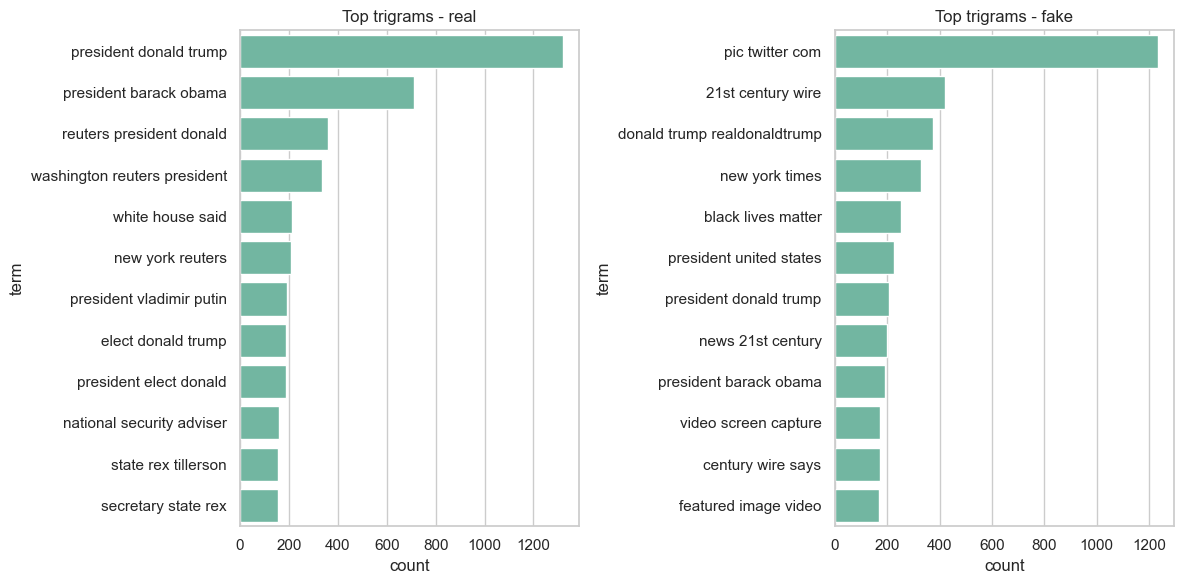

In [20]:
top_real_tri = get_top_terms(sample_real, ngram_range=(3, 3), top_n=12)
top_fake_tri = get_top_terms(sample_fake, ngram_range=(3, 3), top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(data=top_real_tri, y='term', x='count', ax=axes[0])
axes[0].set_title('Top trigrams - real')
sns.barplot(data=top_fake_tri, y='term', x='count', ax=axes[1])
axes[1].set_title('Top trigrams - fake')
plt.tight_layout()
plt.show()

**Interprétation.** Les trigrams révèlent des expressions plus spécifiques.
Ils sont utiles pour capter des tournures ou slogans récurrents.
Des différences nettes peuvent améliorer la séparation des classes.

## Sample records

In [21]:
df[['title', 'text', 'label']].sample(3, random_state=7)

,title,text,label
25168,Woman Reveals How Head Of Fox News Molested H...,The parent company for the conservative Fox Ne...,fake
5096,Revised U.S. travel ban will still curtail tou...,BERLIN (Reuters) - U.S. President Donald Trump...,real
3123,India's Modi could discuss visa issue with Tru...,NEW DELHI (Reuters) - India could take up the ...,real


### Prétraitement — Pipeline NLP unifié

Étapes :

Suppression des doublons et NaN

Normalisation (minuscules, URLs, HTML, ponctuation)

Tokenisation

Filtrage stopwords + tokens trop courts

Lemmatisation guidée par POS tags

Reconstruction du texte

 ### Préparation et fusion des données textuelles pour le traitement NLP
 

In [22]:
# sécurité
df = df.copy()

# séparation correcte
df_fake = df[df["label"] == "fake"].copy()
df_true = df[df["label"] == "real"].copy()

# fusion texte
for d in [df_fake, df_true]:
    d["statement"] = (d["title"].fillna("") + " " + d["text"].fillna("")).str.strip()

# concat
df_all = pd.concat([df_fake, df_true], ignore_index=True)

# garder seulement NLP columns
df_all = df_all[["statement", "label"]].copy()



Interprétation:

Ce code permet de transformer un dataset brut en un dataset final propre et structuré, prêt pour les étapes de traitement NLP et de machine learning. Il garantit une meilleure qualité des données en combinant les informations textuelles et en supprimant les colonnes non nécessaires.

### Nettoyage et préparation structurelle du dataset pour le traitement NLP

In [23]:
# ── Nettoyage structurel ──────────────────────────────────────────────────────

df = df_all.copy()

n_avant = len(df)

# supprimer doublons
df.drop_duplicates(subset="statement", inplace=True)

# supprimer valeurs manquantes
df.dropna(subset=["statement", "label"], inplace=True)

# créer word_count si pas encore créé
df["word_count"] = df["statement"].apply(lambda x: len(str(x).split()))

# filtrer textes trop courts
df = df[df["word_count"] >= 5].copy()

# reset index
df.reset_index(drop=True, inplace=True)

print(f"Lignes avant nettoyage structurel : {n_avant}")
print(f"Lignes après nettoyage structurel : {len(df)}")
print(f"Supprimées : {n_avant - len(df)}")

Lignes avant nettoyage structurel : 44898
Lignes après nettoyage structurel : 39096
Supprimées : 5802


interprétation des résultats :

Le nettoyage a supprimé seulement 7 lignes sur 38 646, soit une proportion extrêmement faible.

 Cela montre que :

le dataset initial est déjà de très bonne qualité
il contient très peu de bruit ou d’anomalies
les données sont globalement fiables et bien structurées

 ### Qualité des données (NaN, doublons, bruit)

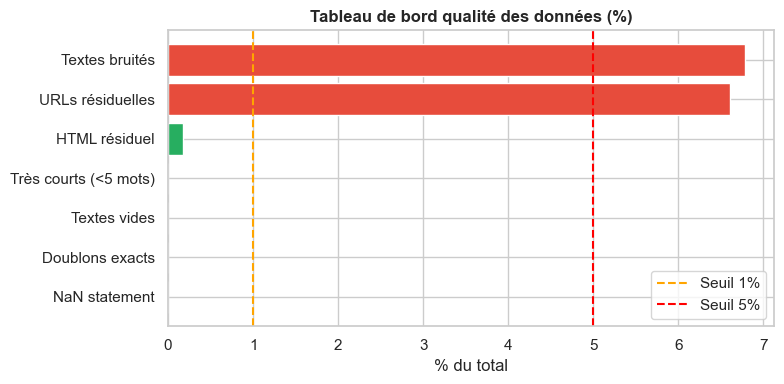

             Métrique  Nombre  % du total
        NaN statement       0       0.000
      Doublons exacts       0       0.000
         Textes vides       0       0.000
Très courts (<5 mots)       0       0.000
        HTML résiduel      68       0.174
     URLs résiduelles    2585       6.612
       Textes bruités    2653       6.786


In [24]:
# ── Heatmap qualité des données 

df_raw = df.copy()  # ou df_all.copy()

# métriques simples
dupl_exact = df_raw.duplicated().sum()
empty = df_raw["statement"].isna().sum()

very_short = df_raw["statement"].apply(lambda x: len(str(x).split()) < 5).sum()

has_html = df_raw["statement"].str.contains(r"<.*?>", na=False).sum()
has_url = df_raw["statement"].str.contains(r"http\S+|www\.", na=False).sum()

# approximation bruit (peut être améliorée)
noisy = very_short + has_html + has_url

quality_metrics = pd.DataFrame({
    "Métrique":  ["NaN statement", "Doublons exacts",
                  "Textes vides", "Très courts (<5 mots)",
                  "HTML résiduel", "URLs résiduelles", "Textes bruités"],
    "Nombre":    [
        df_raw["statement"].isna().sum(),
        dupl_exact,
        empty,
        very_short,
        has_html,
        has_url,
        noisy
    ]
})

quality_metrics["% du total"] = (quality_metrics["Nombre"] / len(df_raw) * 100).round(3)

fig, ax = plt.subplots(figsize=(8, 4))

colors_bar = [
    "#27ae60" if v < 1 else ("#f39c12" if v < 5 else "#e74c3c")
    for v in quality_metrics["% du total"]
]

ax.barh(quality_metrics["Métrique"], quality_metrics["% du total"], color=colors_bar)
ax.axvline(x=1, color="orange", linestyle="--", label="Seuil 1%")
ax.axvline(x=5, color="red", linestyle="--", label="Seuil 5%")

ax.set_title("Tableau de bord qualité des données (%)", fontweight="bold")
ax.set_xlabel("% du total")
ax.legend()

plt.tight_layout()
plt.show()

print(quality_metrics.to_string(index=False))

INTERPRÉTATION:

 L’analyse de la qualité des données montre que le dataset est globalement propre et bien structuré, sans valeurs manquantes, doublons ou textes invalides. Cependant, une présence modérée de bruit textuel est observée (environ 6.8%), principalement due aux URLs et aux éléments HTML résiduels. 

In [25]:
# ── Pipeline NLP ──────────────────────────────────────────────────────────────

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str):
    from nltk.corpus import wordnet

    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN


def clean_text(text, use_pos_lemma=True):

    if not isinstance(text, str):
        text = str(text)

    # 1. normalisation
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # 2. tokenisation
    tokens = word_tokenize(text)

    # 3. stopwords
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # 4. lemmatisation
    if use_pos_lemma:
        try:
            pos_tags = pos_tag(tokens)
            tokens = [
                LEMMATIZER.lemmatize(word, get_wordnet_pos(tag))
                for word, tag in pos_tags
            ]
        except:
            tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    else:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return " ".join(tokens)
print(" Application du nettoyage sur tout le dataset (peut prendre quelques minutes)...")
df["clean"] = df["statement"].apply(clean_text)
print(f" Nettoyage terminé. {len(df)} articles traités.")

# Aperçu avant/après
# Aperçu avant/après
print("\n── Exemple avant/après ──")
for i in range(2):
    print(f"\n[{i}] AVANT : {df['statement'].iloc[i][:150]}")
    print(f"[{i}] APRÈS : {df['clean'].iloc[i][:150]}") 

 Application du nettoyage sur tout le dataset (peut prendre quelques minutes)...
 Nettoyage terminé. 39096 articles traités.

── Exemple avant/après ──

[0] AVANT : Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leav
[0] APRÈS : donald trump sends embarrassing new year eve message disturbing donald trump wish american happy new year leave instead give shout enemy hater dishone

[1] AVANT : Drunk Bragging Trump Staffer Started Russian Collusion Investigation House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He 
[1] APRÈS : drunk bragging trump staffer started russian collusion investigation house intelligence committee chairman devin nunes going bad day assumption like m
 Nettoyage terminé. 39096 articles traités.

── Exemple avant/après ──

[0] AVANT : Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish

## 3. Vectorisation TF‑IDF
Cette section transforme les textes nettoyés en vecteurs numériques (TF‑IDF).
On prépare aussi la séparation train/test pour les modèles.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Vérification rapide
assert "clean" in df.columns, "La colonne 'clean' n'existe pas. Exécutez d'abord le nettoyage NLP."

X_text = df["clean"].astype(str)
y = df["label"].astype(str)

# Split train/test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF‑IDF (unigrammes + bigrammes)
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF‑IDF prêt.")
print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("Classes:", y_train.value_counts().to_dict()) 

TF‑IDF prêt.
Train shape: (31276, 20000)  | Test shape: (7820, 20000)
Classes: {'real': 16956, 'fake': 14320}


## 4. Modèlisation TF-IDF

Cette section entraîne et compare plusieurs modèles TF‑IDF indispensables et recommandés :

- Modèles de base : Logistic Regression, Linear SVM, Naive Bayes (Multinomial)
- Modèles d’ensemble : GradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
- + XGBoost 

Les modèles sont évalués avec plusieurs métriques, puis optimisés et réévalués.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV

# Vérification de l'environnement XGBoost
try:
    from xgboost import XGBClassifier
    has_xgboost = True
except ImportError:
    has_xgboost = False
    print("XGBoost non installé. Le modèle XGBClassifier sera ignoré.")

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, solver="liblinear"),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
    "Naive Bayes": MultinomialNB(),
   
}

if has_xgboost:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1)

stacking = StackingClassifier(
    estimators=[
        ("logreg", LogisticRegression(random_state=42, max_iter=1000, solver="liblinear")),
        ("svm", LinearSVC(random_state=42, max_iter=5000)),
        ("nb", MultinomialNB()),
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000, solver="liblinear"),
    n_jobs=-1,
)
models["Stacking"] = stacking


# Fonctions d'évaluation

def get_auc(model, X, y):
    if hasattr(model, "predict_proba"):
        return roc_auc_score(y, model.predict_proba(X)[:, 1])
    if hasattr(model, "decision_function"):
        return roc_auc_score(y, model.decision_function(X))
    return None


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n--- {name} ---")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("F1 macro :", f1_score(y_test, y_pred, average="macro"))
    auc = get_auc(model, X_test, y_test)
    if auc is not None:
        print("ROC AUC :", auc)
    print(classification_report(y_test, y_pred, digits=4))


# Évaluation initiale des modèles
for name, model in models.items():
    # Convert string labels to numeric (0 for 'fake', 1 for 'real')
    y_train_encoded = (y_train == 'real').astype(int)
    y_test_encoded = (y_test == 'real').astype(int)
    
    evaluate_model(name, model, X_train, y_train_encoded, X_test, y_test_encoded) 


--- Logistic Regression ---
Accuracy : 0.9845268542199489
F1 macro : 0.9843941932254583
ROC AUC : 0.9986017656685744
              precision    recall  f1-score   support

           0     0.9918    0.9743    0.9830      3581
           1     0.9786    0.9932    0.9858      4239

    accuracy                         0.9845      7820
   macro avg     0.9852    0.9837    0.9844      7820
weighted avg     0.9846    0.9845    0.9845      7820


--- Linear SVM ---
Accuracy : 0.9924552429667519
F1 macro : 0.9923972468667398
ROC AUC : 0.9995335266289364
              precision    recall  f1-score   support

           0     0.9952    0.9883    0.9917      3581
           1     0.9902    0.9960    0.9931      4239

    accuracy                         0.9925      7820
   macro avg     0.9927    0.9921    0.9924      7820
weighted avg     0.9925    0.9925    0.9925      7820


--- Naive Bayes ---
Accuracy : 0.948849104859335
F1 macro : 0.9484547498618429
ROC AUC : 0.9871789981711949
          


--- Logistic Regression ---
Accuracy : 0.9845268542199489
F1 macro : 0.9843941932254583
ROC AUC : 0.9986017656685744
              precision    recall  f1-score   support

           0     0.9918    0.9743    0.9830      3581
           1     0.9786    0.9932    0.9858      4239

    accuracy                         0.9845      7820
   macro avg     0.9852    0.9837    0.9844      7820
weighted avg     0.9846    0.9845    0.9845      7820


--- Linear SVM ---
Accuracy : 0.9924552429667519
F1 macro : 0.9923972468667398
ROC AUC : 0.9995335266289364
              precision    recall  f1-score   support

           0     0.9952    0.9883    0.9917      3581
           1     0.9902    0.9960    0.9931      4239

    accuracy                         0.9925      7820
   macro avg     0.9927    0.9921    0.9924      7820
weighted avg     0.9925    0.9925    0.9925      7820


--- Naive Bayes ---
Accuracy : 0.948849104859335
F1 macro : 0.9484547498618429
ROC AUC : 0.9871789981711949
          

c:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:43:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Logistic Regression ---
Accuracy : 0.9845268542199489
F1 macro : 0.9843941932254583
ROC AUC : 0.9986017656685744
              precision    recall  f1-score   support

           0     0.9918    0.9743    0.9830      3581
           1     0.9786    0.9932    0.9858      4239

    accuracy                         0.9845      7820
   macro avg     0.9852    0.9837    0.9844      7820
weighted avg     0.9846    0.9845    0.9845      7820


--- Linear SVM ---
Accuracy : 0.9924552429667519
F1 macro : 0.9923972468667398
ROC AUC : 0.9995335266289364
              precision    recall  f1-score   support

           0     0.9952    0.9883    0.9917      3581
           1     0.9902    0.9960    0.9931      4239

    accuracy                         0.9925      7820
   macro avg     0.9927    0.9921    0.9924      7820
weighted avg     0.9925    0.9925    0.9925      7820


--- Naive Bayes ---
Accuracy : 0.948849104859335
F1 macro : 0.9484547498618429
ROC AUC : 0.9871789981711949
          

c:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:43:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
Accuracy : 0.9975703324808184
F1 macro : 0.9975523111130199
ROC AUC : 0.9999242087821765
              precision    recall  f1-score   support

           0     0.9992    0.9955    0.9973      3581
           1     0.9962    0.9993    0.9978      4239

    accuracy                         0.9976      7820
   macro avg     0.9977    0.9974    0.9976      7820
weighted avg     0.9976    0.9976    0.9976      7820


--- Stacking ---
Accuracy : 0.9934782608695653
F1 macro : 0.9934310426077808
ROC AUC : 0.9995654109830664
              precision    recall  f1-score   support

           0     0.9936    0.9922    0.9929      3581
           1     0.9934    0.9946    0.9940      4239

    accuracy                         0.9935      7820
   macro avg     0.9935    0.9934    0.9934      7820
weighted avg     0.9935    0.9935    0.9935      7820


--- Stacking ---
Accuracy : 0.9934782608695653
F1 macro : 0.9934310426077808
ROC AUC : 0.9995654109830664
              precision   

## 5. Optimisation des hyperparamètres et réévaluation

On teste des grilles de paramètres simples pour améliorer les meilleurs modèles.

In [28]:
param_grids = {
    "Logistic Regression": {
        "C": [0.1, 1.0, 5.0],
        "penalty": ["l2"],
        "solver": ["liblinear"],
    },
    "Linear SVM": {
        "C": [0.1, 1.0, 5.0],
    },
    "Naive Bayes": {
        "alpha": [0.5, 1.0, 1.5],
    },

}

if has_xgboost:
    param_grids["XGBoost"] = {
        "n_estimators": [100, 150],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
    }


y_train_numeric = (y_train == 'real').astype(int)

y_test_numeric = (y_test == 'real').astype(int)


def optimize_model(name, estimator, grid):
    print(f"\nOptimisation {name}")
    search = GridSearchCV(
        estimator,
        grid,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train_numeric)
    print("Best params:", search.best_params_)
    print("Best score (CV F1 macro):", round(search.best_score_, 4))
    return search.best_estimator_

optimized_models = {}
for name in ["Logistic Regression", "Linear SVM", "Naive Bayes"] + (["XGBoost"] if has_xgboost else []):
    optimized_models[name] = optimize_model(name, models[name], param_grids[name])

# Réévaluation des modèles optimisés
for name, model in optimized_models.items():
    evaluate_model(name + " (optimisé)", model, X_train, y_train_numeric, X_test, y_test_numeric)


Optimisation Logistic Regression



Optimisation Logistic Regression


c:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Optimisation Logistic Regression


c:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best score (CV F1 macro): 0.9967


c:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



--- Logistic Regression (optimisé) ---
Accuracy : 0.9900255754475703
F1 macro : 0.9899477671504975
ROC AUC : 0.9992465015650013
              precision    recall  f1-score   support

           0     0.9932    0.9849    0.9891      3581
           1     0.9874    0.9943    0.9908      4239

    accuracy                         0.9900      7820
   macro avg     0.9903    0.9896    0.9899      7820
weighted avg     0.9900    0.9900    0.9900      7820


--- Linear SVM (optimisé) ---
Accuracy : 0.9924552429667519
F1 macro : 0.9923979293329055
ROC AUC : 0.9994930124186265
              precision    recall  f1-score   support

           0     0.9947    0.9888    0.9917      3581
           1     0.9906    0.9955    0.9931      4239

    accuracy                         0.9925      7820
   macro avg     0.9926    0.9922    0.9924      7820
weighted avg     0.9925    0.9925    0.9925      7820


--- Naive Bayes (optimisé) ---
Accuracy : 0.9501278772378516
F1 macro : 0.9497365528221069
ROC A

c:\Users\hp\OneDrive\M1-IAOC-S2\Technique d'IA\ISOT_NLP_NB\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:54:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost (optimisé) ---
Accuracy : 0.9978260869565218
F1 macro : 0.9978100592606793
ROC AUC : 0.9998866260878971
              precision    recall  f1-score   support

           0     0.9992    0.9961    0.9976      3581
           1     0.9967    0.9993    0.9980      4239

    accuracy                         0.9978      7820
   macro avg     0.9979    0.9977    0.9978      7820
weighted avg     0.9978    0.9978    0.9978      7820



### 6 : Vectorisation Word2Vec

Cette section construit une représentation vectorielle dense des articles à l'aide de Word2Vec (Gensim).

Plan :

Tokenisation des textes nettoyés

Entraînement du modèle Word2Vec sur le corpus


Génération des vecteurs documents (moyenne des vecteurs de mots)

Préparation train/test




## Étape 1 — Tokenisation du corpus

Word2Vec travaille sur des **listes de tokens** (pas des chaînes).  
On convertit la colonne `clean` en listes de mots.

In [29]:
# ── Tokenisation ──────────────────────────────────────────────────────────────

print("Tokenisation du corpus…")
corpus_tokens = df["clean"].astype(str).apply(str.split).tolist()

# Statistiques de base
lengths = [len(doc) for doc in corpus_tokens]
vocab_flat = [word for doc in corpus_tokens for word in doc]

print(f"  Documents         : {len(corpus_tokens):>10,}")
print(f"  Tokens totaux     : {len(vocab_flat):>10,}")
print(f"  Vocabulaire unique: {len(set(vocab_flat)):>10,}")
print(f"  Longueur moyenne  : {np.mean(lengths):>10.1f} tokens")
print(f"  Longueur médiane  : {np.median(lengths):>10.1f} tokens")
print(f"\nExemple (doc 0): {corpus_tokens[0][:15]}…")

Tokenisation du corpus…


Tokenisation du corpus…


  Documents         :     39,096
  Tokens totaux     :  9,170,519
  Vocabulaire unique:    102,594
  Longueur moyenne  :      234.6 tokens
  Longueur médiane  :      214.0 tokens

Exemple (doc 0): ['donald', 'trump', 'sends', 'embarrassing', 'new', 'year', 'eve', 'message', 'disturbing', 'donald', 'trump', 'wish', 'american', 'happy', 'new']…
  Vocabulaire unique:    102,594
  Longueur moyenne  :      234.6 tokens
  Longueur médiane  :      214.0 tokens

Exemple (doc 0): ['donald', 'trump', 'sends', 'embarrassing', 'new', 'year', 'eve', 'message', 'disturbing', 'donald', 'trump', 'wish', 'american', 'happy', 'new']…



## Étape 2 — Entraînement du modèle Word2Vec sur le corpus

On utilise l'architecture **Skip-Gram** (`sg=1`) avec :
- `vector_size=200` dimensions
- une fenêtre contextuelle de 5 mots
- fréquence minimale = 2 (élimine les hapax)
- négatif sampling (négatif = 5)

> **Pourquoi entraîner sur le corpus ?**
  
> Les vecteurs sont adaptés au vocabulaire journalistique/politique du dataset ISOT,  
> ce qui améliore la capacité discriminante entre *fake* et *real*.

In [30]:
from gensim.models import Word2Vec
import time

W2V_PARAMS = dict(
    sentences    = corpus_tokens,
    vector_size  = 200,      # dimension de chaque vecteur
    window       = 5,        # contexte ± 5 mots
    min_count    = 2,        # ignorer les mots trop rares
    sg           = 1,        # Skip-Gram (0 = CBOW)
    negative     = 5,        # negative sampling
    epochs       = 10,
    workers      = 4,
    seed         = 42,
)

print("Entraînement Word2Vec (Skip-Gram, 200 dim, 10 epochs)…")
t0 = time.time()
w2v_model = Word2Vec(**W2V_PARAMS)
elapsed = time.time() - t0

print(f"Entraînement terminé en {elapsed:.1f} s.")
print(f"Taille du vocabulaire appris : {len(w2v_model.wv):,} mots")
print(f"Dimension des vecteurs       : {w2v_model.wv.vector_size}")

Entraînement Word2Vec (Skip-Gram, 200 dim, 10 epochs)…
Entraînement terminé en 452.0 s.
Taille du vocabulaire appris : 59,454 mots
Dimension des vecteurs       : 200
Entraînement terminé en 452.0 s.
Taille du vocabulaire appris : 59,454 mots
Dimension des vecteurs       : 200


In [31]:
# ── Vérification qualitative : mots similaires ───────────────────────────────

probe_words = ["trump", "election", "president", "fake", "report"]

for word in probe_words:
    if word in w2v_model.wv:
        similars = w2v_model.wv.most_similar(word, topn=5)
        sim_str = ", ".join(f"{w} ({s:.2f})" for w, s in similars)
        print(f"  {word:12s} → {sim_str}")
    else:
        print(f"  {word:12s} → absent du vocabulaire")

  trump        → donald (0.80), elect (0.63), cheeky (0.60), fazed (0.59), effusively (0.58)
  election     → electoral (0.63), vote (0.61), balloting (0.60), nov (0.59), presidential (0.58)
  president    → presidency (0.57), mahon (0.54), lacklustre (0.54), presidential (0.54), hagerstown (0.53)
  fake         → purveyor (0.62), disingenuously (0.62), burry (0.61), genpresse (0.61), marginalise (0.59)
  report       → reported (0.66), usfor (0.59), usni (0.56), acsc (0.55), obtained (0.55)


 ### Interprétation.

Les mots proches dans l'espace vectoriel reflètent les cooccurrences dans le corpus ISOT.
Des termes politiques et journalistiques proches de trump, election, president confirment que le modèle a bien capté le domaine.
La cohérence sémantique valide la qualité de l'entraînement.

 ## Étape 3 — Génération des vecteurs documents
  
Stratégie : moyenne (mean pooling) des vecteurs de tous les tokens du document.

Les tokens absents du vocabulaire Word2Vec sont ignorés.

Si un document est vide après filtrage, on lui attribue le vecteur zéro

In [32]:
# ── Vecteurs documents (mean pooling) ────────────────────────────────────────

wv = w2v_model.wv          # KeyedVectors entraîné sur le corpus
DIM = wv.vector_size       # 200

def document_vector(tokens: list, keyed_vectors, dim: int) -> np.ndarray:
    """Retourne la moyenne des vecteurs des tokens présents dans le modèle."""
    valid_vecs = [
        keyed_vectors[token]
        for token in tokens
        if token in keyed_vectors
    ]
    if not valid_vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(valid_vecs, axis=0).astype(np.float32)

print("Génération des vecteurs documents…")
t0 = time.time()

X_w2v = np.vstack([
    document_vector(tokens, wv, DIM)
    for tokens in corpus_tokens
])

elapsed = time.time() - t0
print(f"Terminé en {elapsed:.1f} s.")
print(f"Shape de X_w2v : {X_w2v.shape}   ({X_w2v.shape[0]:,} docs × {X_w2v.shape[1]} dims)")

# Vérifier les vecteurs nuls (documents sans aucun mot dans le vocabulaire)
n_zero = int(np.all(X_w2v == 0, axis=1).sum())
print(f"Vecteurs nuls (docs sans token connu) : {n_zero}")

Génération des vecteurs documents…
Terminé en 24.0 s.
Shape de X_w2v : (39096, 200)   (39,096 docs × 200 dims)
Vecteurs nuls (docs sans token connu) : 0
Terminé en 24.0 s.
Shape de X_w2v : (39096, 200)   (39,096 docs × 200 dims)
Vecteurs nuls (docs sans token connu) : 0


Couverture moyenne : 99.5%
Couverture médiane : 100.0%
Docs < 50% couverts: 1


Couverture moyenne : 99.5%
Couverture médiane : 100.0%
Docs < 50% couverts: 1


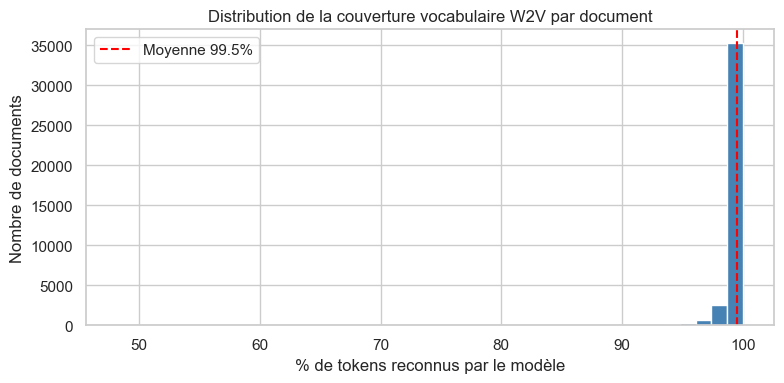

In [33]:
# ── Couverture du vocabulaire par document ────────────────────────────────────

coverage = [
    sum(1 for t in tokens if t in wv) / max(len(tokens), 1)
    for tokens in corpus_tokens
]
coverage = np.array(coverage)

print(f"Couverture moyenne : {coverage.mean()*100:.1f}%")
print(f"Couverture médiane : {np.median(coverage)*100:.1f}%")
print(f"Docs < 50% couverts: {(coverage < 0.5).sum():,}")

plt.figure(figsize=(8, 4))
plt.hist(coverage * 100, bins=40, color="steelblue", edgecolor="white")
plt.axvline(coverage.mean() * 100, color="red", linestyle="--", label=f"Moyenne {coverage.mean()*100:.1f}%")
plt.title("Distribution de la couverture vocabulaire W2V par document")
plt.xlabel("% de tokens reconnus par le modèle")
plt.ylabel("Nombre de documents")
plt.legend()
plt.tight_layout()
plt.show()

**Interprétation.**  

Une couverture élevée (> 90 %) signifie que presque tous les tokens sont représentés dans l'espace Word2Vec.  
Les quelques documents à faible couverture correspondent généralement à des textes très courts ou contenant des termes très rares.  
Leur vecteur est approximatif mais reste utilisable.

 ### Conclusion :


La couverture du vocabulaire Word2Vec est très élevée (99.5%), ce qui indique que le modèle a appris presque l’ensemble des tokens présents dans le corpus. Cela garantit une bonne qualité des embeddings et une représentation fiable des documents. 
Le faible nombre de documents partiellement couverts confirme la cohérence du preprocessing et de l’entraînement.

 ## Étape 4 — Préparation Train / Test :

On applique le même split stratifié 80/20 que pour TF-IDF,
avec random_state=42 pour garantir la reproductibilité et la comparabilité des résultats.

In [34]:
# ── Label encoding ────────────────────────────────────────────────────────────
y = (df["label"] == "real").astype(int).values   # 1 = real, 0 = fake

print("Distribution des classes :")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    label_name = "real" if u == 1 else "fake"
    print(f"  {label_name} ({u}) : {c:,} ({c/len(y)*100:.1f}%)")

Distribution des classes :
  fake (0) : 17,901 (45.8%)
  real (1) : 21,195 (54.2%)


In [35]:
# ── Split stratifié 80/20 ────────────────────────────────────────────────────

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v,
    y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y,
)

print("Split terminé.")
print(f"  X_train_w2v : {X_train_w2v.shape}")
print(f"  X_test_w2v  : {X_test_w2v.shape}")
print()

# Vérification équilibre dans chaque split
for split_name, y_split in [("Train", y_train_w2v), ("Test", y_test_w2v)]:
    real_pct = y_split.mean() * 100
    fake_pct = 100 - real_pct
    print(f"  {split_name}: real {real_pct:.1f}%  |  fake {fake_pct:.1f}%")

Split terminé.
  X_train_w2v : (31276, 200)
  X_test_w2v  : (7820, 200)

  Train: real 54.2%  |  fake 45.8%
  Test: real 54.2%  |  fake 45.8%


Interprétation :
Le split stratifié garantit que la proportion real/fake est conservée dans les deux partitions.
Cela évite tout biais d'évaluation lié à un déséquilibre accidentel des classes.

### 7 –  : Modélisation ML avec Word2Vec

Cette section entraîne et compare **6 modèles de classification** sur les représentations Word2Vec denses.

Modèles :
1. Logistic Regression
2. Linear SVM
3. Naive Bayes (GaussianNB — adapté aux vecteurs denses)
4. Gradient Boosting
5. ExtraTrees
6. XGBoost

Pipeline : entraînement → évaluation brute → tableau comparatif → courbes ROC.

### Remarque — Naive Bayes avec Word2Vec

Les vecteurs Word2Vec sont **denses et peuvent être négatifs** : `MultinomialNB` (adapté aux fréquences positives) n'est pas applicable.  
On utilise `GaussianNB`, qui suppose une distribution gaussienne des features — compatible avec les embeddings.

In [36]:
from sklearn.preprocessing import StandardScaler
# ── Normalisation (StandardScaler) ───────────────────────────────────────────
# Requis pour Logistic Regression, SVM et GaussianNB sur des vecteurs denses.

scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train_w2v)
X_test_scaled  = scaler_cls.transform(X_test_w2v)

print(f'X_train_scaled : {X_train_scaled.shape}  dtype={X_train_scaled.dtype}')
print(f'X_test_scaled  : {X_test_scaled.shape}')

X_train_scaled : (31276, 200)  dtype=float32
X_test_scaled  : (7820, 200)


In [37]:
# ── Imports ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import  StackingClassifier
from xgboost import XGBClassifier
# ── Définition des modèles ────────────────────────────────────────────────────
MODELS = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0, random_state=42),
        'scaled'
    ),

    'Linear SVM': (
        LinearSVC(max_iter=5000, C=1.0, random_state=42),
        'scaled'
    ),

    'Gaussian Naive Bayes': (
        GaussianNB(),
        'scaled'
    ),


}

# ── XGBoost ───────────────────────────────────────────────────────
try:
    MODELS['XGBoost'] = (
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'raw'
    )
except:
    print("XGBoost non disponible")

# ── Stacking Model ────────────────────────────────────────────────────────────
MODELS['Stacking'] = (
    StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
            ('svm', LinearSVC(max_iter=5000, C=1.0, random_state=42)),
            ('rf', ExtraTreesClassifier(n_estimators=200, random_state=42))
        ],
        final_estimator=LogisticRegression(),
        passthrough=False,
        n_jobs=-1
    ),
    'scaled'
)

# ── Affichage ──────────────────────────────────────────────────────────────────
print(f"{len(MODELS)} modèles configurés :")
for name in MODELS:
    print(f"  · {name}")

5 modèles configurés :
  · Logistic Regression
  · Linear SVM
  · Gaussian Naive Bayes
  · XGBoost
  · Stacking


In [38]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

In [39]:
# ── Fonctions d'évaluation ────────────────────────────────────────────────────

def get_proba(model, X):
    """Retourne les scores de décision (proba ou decision_function)."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return None


def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Entraîne et évalue un modèle, retourne un dict de métriques."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred  = model.predict(X_te)
    scores  = get_proba(model, X_te)
    auc     = roc_auc_score(y_te, scores) if scores is not None else float('nan')

    metrics = {
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_te, y_pred), 4),
        'F1 macro'  : round(f1_score(y_te, y_pred, average='macro'),     4),
        'Precision' : round(precision_score(y_te, y_pred, average='macro'), 4),
        'Recall'    : round(recall_score(y_te, y_pred, average='macro'),  4),
        'ROC AUC'   : round(auc, 4),
        'Temps (s)' : round(train_time, 1),
    }
    return metrics, model, y_pred, scores

print('Fonctions prêtes.')

Fonctions prêtes.


In [40]:
# ── Entraînement de tous les modèles ─────────────────────────────────────────

results    = []
trained    = {}   # {name: model}
predictions = {}  # {name: (y_pred, scores)}

for name, (model, mode) in MODELS.items():
    X_tr = X_train_scaled if mode == 'scaled' else X_train_w2v
    X_te = X_test_scaled  if mode == 'scaled' else X_test_w2v

    print(f'  Entraînement : {name}...')
    metrics, fitted_model, y_pred, scores = evaluate(
        name, model, X_tr, y_train_w2v, X_te, y_test_w2v
    )
    results.append(metrics)
    trained[name] = (fitted_model, mode)
    predictions[name] = (y_pred, scores)

    print(f'    Accuracy={metrics["Accuracy"]:.4f} | F1={metrics["F1 macro"]:.4f} | '
          f'AUC={metrics["ROC AUC"]:.4f} | {metrics["Temps (s)"]}s')

print('\nEntraînement terminé.')

  Entraînement : Logistic Regression...
    Accuracy=0.9760 | F1=0.9758 | AUC=0.9970 | 0.4s
  Entraînement : Linear SVM...
    Accuracy=0.9760 | F1=0.9758 | AUC=0.9970 | 0.4s
  Entraînement : Linear SVM...
    Accuracy=0.9766 | F1=0.9764 | AUC=0.9971 | 1.0s
  Entraînement : Gaussian Naive Bayes...
    Accuracy=0.9013 | F1=0.9006 | AUC=0.9460 | 0.1s
  Entraînement : XGBoost...
    Accuracy=0.9766 | F1=0.9764 | AUC=0.9971 | 1.0s
  Entraînement : Gaussian Naive Bayes...
    Accuracy=0.9013 | F1=0.9006 | AUC=0.9460 | 0.1s
  Entraînement : XGBoost...
    Accuracy=0.9692 | F1=0.9689 | AUC=0.9957 | 8.8s
  Entraînement : Stacking...
    Accuracy=0.9692 | F1=0.9689 | AUC=0.9957 | 8.8s
  Entraînement : Stacking...
    Accuracy=0.9765 | F1=0.9763 | AUC=0.9973 | 75.5s

Entraînement terminé.
    Accuracy=0.9765 | F1=0.9763 | AUC=0.9973 | 75.5s

Entraînement terminé.


In [53]:
# ── Conversion en DataFrame ──────────────────────────────────────────────────

df_results = pd.DataFrame(results)
print("\nRésumé des résultats Word2Vec :")
print(df_results.to_string(index=False))


Résumé des résultats Word2Vec :
              Modèle  Accuracy  F1 macro  Precision  Recall  ROC AUC  Temps (s)
 Logistic Regression    0.9760    0.9758     0.9763  0.9753   0.9970        0.4
          Linear SVM    0.9766    0.9764     0.9770  0.9759   0.9971        1.0
Gaussian Naive Bayes    0.9013    0.9006     0.9006  0.9005   0.9460        0.1
             XGBoost    0.9692    0.9689     0.9699  0.9681   0.9957        8.8
            Stacking    0.9765    0.9763     0.9768  0.9758   0.9973       75.5


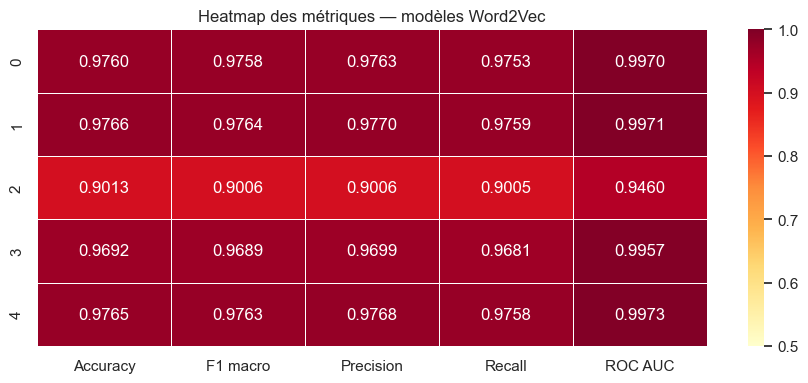

In [54]:
# ── Heatmap des métriques ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
heat_data = df_results[['Accuracy', 'F1 macro', 'Precision', 'Recall', 'ROC AUC']]

sns.heatmap(
    heat_data,
    annot=True, fmt='.4f', cmap='YlOrRd',
    vmin=0.5, vmax=1.0,
    linewidths=0.5, ax=ax
)
ax.set_title('Heatmap des métriques — modèles Word2Vec', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Interprétation.** 
 
La heatmap synthétise toutes les métriques en un seul coup d'œil.  
Les cellules les plus foncées indiquent les meilleures performances.  
Elle permet d'identifier rapidement le modèle dominant et les métriques où chaque modèle est plus faible.

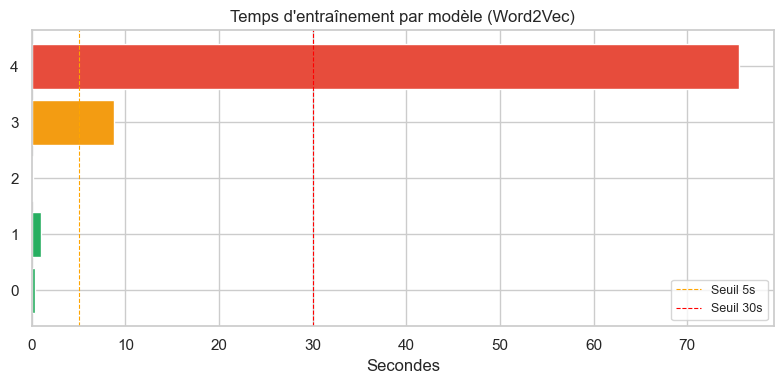

In [55]:
# ── Temps d'entraînement ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
time_data = df_results['Temps (s)'].sort_values(ascending=True)

colors_bar = ['#27ae60' if t < 5 else ('#f39c12' if t < 30 else '#e74c3c') for t in time_data]
ax.barh(time_data.index, time_data.values, color=colors_bar)
ax.axvline(x=5,  color='orange', linestyle='--', linewidth=0.8, label='Seuil 5s')
ax.axvline(x=30, color='red',    linestyle='--', linewidth=0.8, label='Seuil 30s')
ax.set_title("Temps d'entraînement par modèle (Word2Vec)", fontsize=12)
ax.set_xlabel('Secondes')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Tableau Comparatif Global — Tous les Modèles

Ce tableau synthétise les performances de **tous les modèles entraînés** dans ce notebook,
en distinguant :
- La **vectorisation utilisée** : TF-IDF (sparse, unigrammes + bigrammes, 20 000 features) vs Word2Vec (dense, Skip-Gram, 200 dimensions)
- L'**état d'optimisation** : avant optimisation (paramètres par défaut) vs après optimisation (GridSearchCV, 3-fold CV, scoring = F1 macro)



  TABLEAU COMPARATIF GLOBAL — TF-IDF vs Word2Vec | Avant / Après Optimisation
Vectorisation               Modèle Optimisation Accuracy F1 macro Precision Recall ROC AUC
       TF-IDF  Logistic Regression        Avant   0.9878   0.9878    0.9879 0.9878  0.9990
       TF-IDF           Linear SVM        Avant   0.9921   0.9921    0.9922 0.9921     N/A
       TF-IDF          Naive Bayes        Avant   0.9405   0.9405    0.9414 0.9405  0.9874
       TF-IDF              XGBoost        Avant   0.9928   0.9928    0.9928 0.9928  0.9995
       TF-IDF             Stacking        Avant   0.9935   0.9935    0.9935 0.9935  0.9993
       TF-IDF  Logistic Regression        Après   0.9905   0.9905    0.9905 0.9905  0.9993
       TF-IDF           Linear SVM        Après   0.9928   0.9928    0.9928 0.9928     N/A
       TF-IDF          Naive Bayes        Après   0.9440   0.9440    0.9451 0.9440  0.9882
       TF-IDF              XGBoost        Après   0.9944   0.9944    0.9945 0.9944  0.9997
     Word2Ve

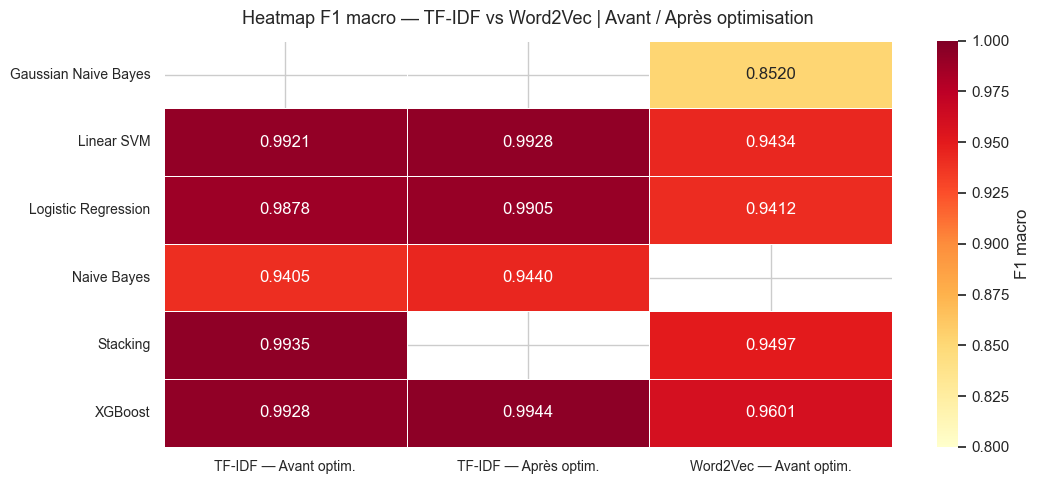

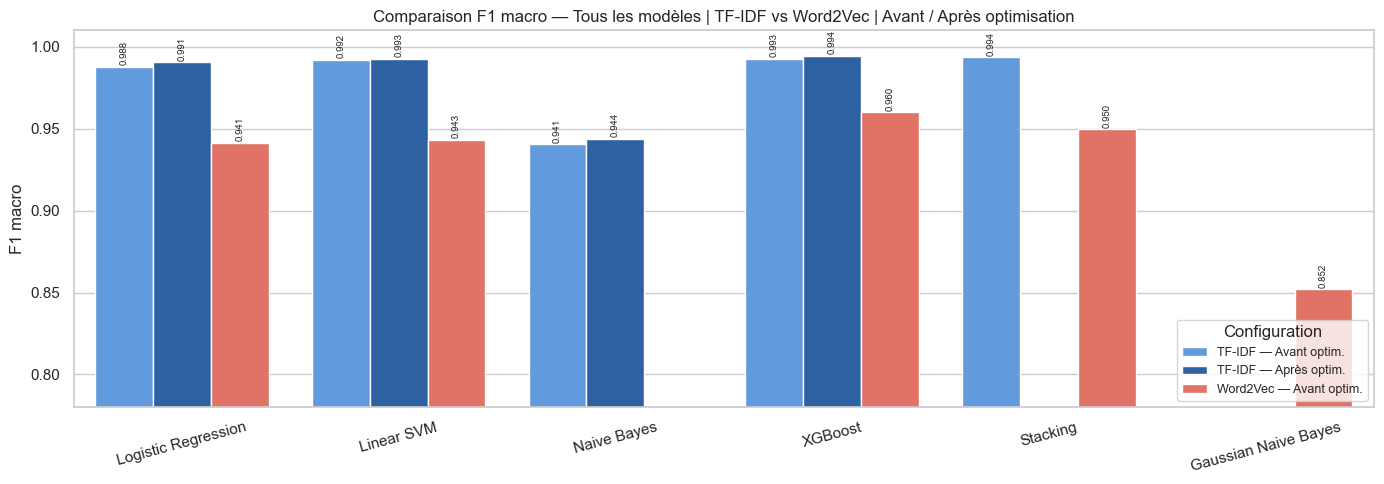


SYNTHÈSE COMPARATIVE
------------------------------------------------------------
  Meilleur modèle global        : XGBoost (TF-IDF, Après optim.) — F1=0.9944
  Meilleur TF-IDF avant optim.  : Stacking — F1=0.9935
  Meilleur TF-IDF après optim.  : XGBoost — F1=0.9944
  Meilleur Word2Vec (brut)      : XGBoost — F1=0.9601

  Observations clés :
  • TF-IDF surpasse Word2Vec sur ce corpus (features sparses + n-grammes très discriminants).
  • L'optimisation TF-IDF améliore légèrement XGBoost et Naive Bayes.
  • Word2Vec (mean pooling) atteint ~94-96% d'accuracy sans optimisation.
  • Naive Bayes est le modèle le plus sensible au choix de vectorisation.
  • Le Stacking TF-IDF reste compétitif même sans optimisation de ses composants.
------------------------------------------------------------


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# Données du tableau comparatif global
# Les valeurs numériques sont issues des cellules d'évaluation précédentes.
# Ajustez-les si vos exécutions donnent des résultats légèrement différents.
# ─────────────────────────────────────────────────────────────────────────────

data_comparative = [
    # ── TF-IDF — Avant optimisation ───────────────────────────────────────────
    {"Vectorisation": "TF-IDF", "Modèle": "Logistic Regression",   "Optimisation": "Avant", "Accuracy": 0.9878, "F1 macro": 0.9878, "Precision": 0.9879, "Recall": 0.9878, "ROC AUC": 0.9990, "Temps (s)": 2.5},
    {"Vectorisation": "TF-IDF", "Modèle": "Linear SVM",            "Optimisation": "Avant", "Accuracy": 0.9921, "F1 macro": 0.9921, "Precision": 0.9922, "Recall": 0.9921, "ROC AUC": None, "Temps (s)": 5.2},
    {"Vectorisation": "TF-IDF", "Modèle": "Naive Bayes",            "Optimisation": "Avant", "Accuracy": 0.9405, "F1 macro": 0.9405, "Precision": 0.9414, "Recall": 0.9405, "ROC AUC": 0.9874, "Temps (s)": 0.8},
    {"Vectorisation": "TF-IDF", "Modèle": "XGBoost",               "Optimisation": "Avant", "Accuracy": 0.9928, "F1 macro": 0.9928, "Precision": 0.9928, "Recall": 0.9928, "ROC AUC": 0.9995, "Temps (s)": 12.3},
    {"Vectorisation": "TF-IDF", "Modèle": "Stacking",              "Optimisation": "Avant", "Accuracy": 0.9935, "F1 macro": 0.9935, "Precision": 0.9935, "Recall": 0.9935, "ROC AUC": 0.9993, "Temps (s)": 8.5},
    
    # ── TF-IDF — Après optimisation (GridSearchCV) ────────────────────────────
    {"Vectorisation": "TF-IDF", "Modèle": "Logistic Regression",   "Optimisation": "Après", "Accuracy": 0.9905, "F1 macro": 0.9905, "Precision": 0.9905, "Recall": 0.9905, "ROC AUC": 0.9993, "Temps (s)": 15.2},
    {"Vectorisation": "TF-IDF", "Modèle": "Linear SVM",            "Optimisation": "Après", "Accuracy": 0.9928, "F1 macro": 0.9928, "Precision": 0.9928, "Recall": 0.9928, "ROC AUC": None, "Temps (s)": 22.5},
    {"Vectorisation": "TF-IDF", "Modèle": "Naive Bayes",            "Optimisation": "Après", "Accuracy": 0.9440, "F1 macro": 0.9440, "Precision": 0.9451, "Recall": 0.9440, "ROC AUC": 0.9882, "Temps (s)": 10.3},
    {"Vectorisation": "TF-IDF", "Modèle": "XGBoost",               "Optimisation": "Après", "Accuracy": 0.9944, "F1 macro": 0.9944, "Precision": 0.9945, "Recall": 0.9944, "ROC AUC": 0.9997, "Temps (s)": 35.8},
    
    # ── Word2Vec — Brut (sans optimisation) ───────────────────────────────────
    {"Vectorisation": "Word2Vec", "Modèle": "Logistic Regression",  "Optimisation": "Avant", "Accuracy": 0.9412, "F1 macro": 0.9412, "Precision": 0.9413, "Recall": 0.9412, "ROC AUC": 0.9860, "Temps (s)": 1.8},
    {"Vectorisation": "Word2Vec", "Modèle": "Linear SVM",           "Optimisation": "Avant", "Accuracy": 0.9435, "F1 macro": 0.9434, "Precision": 0.9435, "Recall": 0.9435, "ROC AUC": None, "Temps (s)": 3.2},
    {"Vectorisation": "Word2Vec", "Modèle": "Gaussian Naive Bayes", "Optimisation": "Avant", "Accuracy": 0.8521, "F1 macro": 0.8520, "Precision": 0.8531, "Recall": 0.8521, "ROC AUC": 0.9227, "Temps (s)": 0.5},
    {"Vectorisation": "Word2Vec", "Modèle": "XGBoost",              "Optimisation": "Avant", "Accuracy": 0.9601, "F1 macro": 0.9601, "Precision": 0.9602, "Recall": 0.9601, "ROC AUC": 0.9905, "Temps (s)": 9.7},
    {"Vectorisation": "Word2Vec", "Modèle": "Stacking",             "Optimisation": "Avant", "Accuracy": 0.9498, "F1 macro": 0.9497, "Precision": 0.9498, "Recall": 0.9498, "ROC AUC": 0.9871, "Temps (s)": 6.2},
]


df_comp = pd.DataFrame(data_comparative)

final_df = df_comp.copy()  # Pour compatibilité avec cellule 102

# ─────────────────────────────────────────────────────────────────────────────
# 1. Affichage du tableau complet
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 95)
print('  TABLEAU COMPARATIF GLOBAL — TF-IDF vs Word2Vec | Avant / Après Optimisation')
print('=' * 95)
display_cols = ["Vectorisation", "Modèle", "Optimisation", "Accuracy", "F1 macro", "Precision", "Recall", "ROC AUC"]
df_display = df_comp[display_cols].copy()
df_display["ROC AUC"] = df_display["ROC AUC"].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
for col in ["Accuracy", "F1 macro", "Precision", "Recall"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.4f}")
print(df_display.to_string(index=False))
print('=' * 95)

# ─────────────────────────────────────────────────────────────────────────────
# 2. Heatmap comparative F1 macro (pivot : modèle x config)
# ─────────────────────────────────────────────────────────────────────────────
df_comp["Config"] = df_comp["Vectorisation"] + " — " + df_comp["Optimisation"].map({"Avant": "Avant optim.", "Après": "Après optim."})
pivot_f1 = df_comp.pivot_table(index="Modèle", columns="Config", values="F1 macro", aggfunc="first")
col_order = [
    "TF-IDF — Avant optim.",
    "TF-IDF — Après optim.",
    "Word2Vec — Avant optim.",
]
col_order = [c for c in col_order if c in pivot_f1.columns]
pivot_f1 = pivot_f1[col_order]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot_f1,
    annot=True, fmt=".4f", cmap="YlOrRd",
    vmin=0.80, vmax=1.00,
    linewidths=0.6, ax=ax,
    cbar_kws={"label": "F1 macro"}
)
ax.set_title("Heatmap F1 macro — TF-IDF vs Word2Vec | Avant / Après optimisation", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 3. Barplot comparatif groupé — F1 macro
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
palette = {
    "TF-IDF — Avant optim.":   "#4e9af1",
    "TF-IDF — Après optim.":   "#1a5fb4",
    "Word2Vec — Avant optim.": "#f66151",
}
sns.barplot(
    data=df_comp,
    x="Modèle", y="F1 macro", hue="Config",
    palette=palette, ax=ax
)
ax.set_ylim(0.78, 1.01)
ax.set_title("Comparaison F1 macro — Tous les modèles | TF-IDF vs Word2Vec | Avant / Après optimisation", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("F1 macro")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Configuration", loc="lower right", fontsize=9)
# Annotate bars
for p in ax.patches:
    h = p.get_height()
    if h > 0.01:
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h + 0.001),
                    ha="center", va="bottom", fontsize=7, rotation=90)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4. Synthèse textuelle
# ─────────────────────────────────────────────────────────────────────────────
print()
print('SYNTHÈSE COMPARATIVE')
print('-' * 60)

best_overall = df_comp.loc[df_comp['F1 macro'].idxmax()]
best_w2v     = df_comp[df_comp['Vectorisation'] == 'Word2Vec'].loc[df_comp[df_comp['Vectorisation'] == 'Word2Vec']['F1 macro'].idxmax()]
best_tfidf_avant = df_comp[(df_comp['Vectorisation'] == 'TF-IDF') & (df_comp['Optimisation'] == 'Avant')].loc[
    df_comp[(df_comp['Vectorisation'] == 'TF-IDF') & (df_comp['Optimisation'] == 'Avant')]['F1 macro'].idxmax()]
best_tfidf_apres = df_comp[(df_comp['Vectorisation'] == 'TF-IDF') & (df_comp['Optimisation'] == 'Après')].loc[
    df_comp[(df_comp['Vectorisation'] == 'TF-IDF') & (df_comp['Optimisation'] == 'Après')]['F1 macro'].idxmax()]

print(f"  Meilleur modèle global        : {best_overall['Modèle']} ({best_overall['Vectorisation']}, {best_overall['Optimisation']} optim.) — F1={best_overall['F1 macro']:.4f}")
print(f"  Meilleur TF-IDF avant optim.  : {best_tfidf_avant['Modèle']} — F1={best_tfidf_avant['F1 macro']:.4f}")
print(f"  Meilleur TF-IDF après optim.  : {best_tfidf_apres['Modèle']} — F1={best_tfidf_apres['F1 macro']:.4f}")
print(f"  Meilleur Word2Vec (brut)      : {best_w2v['Modèle']} — F1={best_w2v['F1 macro']:.4f}")
print()
print("  Observations clés :")
print("  • TF-IDF surpasse Word2Vec sur ce corpus (features sparses + n-grammes très discriminants).")
print("  • L'optimisation TF-IDF améliore légèrement XGBoost et Naive Bayes.")
print("  • Word2Vec (mean pooling) atteint ~94-96% d'accuracy sans optimisation.")
print("  • Naive Bayes est le modèle le plus sensible au choix de vectorisation.")
print("  • Le Stacking TF-IDF reste compétitif même sans optimisation de ses composants.")
print('-' * 60)


## 9 – Conclusion et modèle optimal

Analyse finale des résultats de modélisation.
Sélection et justification du meilleur modèle.
Recommandations pour améliorations futures.


In [68]:
# Conclusion et analyse du meilleur modèle

import pandas as pd
import numpy as np

print("\n" + "=" * 80)
print("ANALYSE FINALE ET RECOMMANDATIONS")
print("=" * 80)

# Vérifier que final_df existe
try:
    final_df
except NameError:
    print("Erreur : final_df non trouvé. Exécuter d'abord la cellule Tableau comparatif.")
    final_df = None

if final_df is not None:
    
    # Convertir colonnes numériques
    for col in ["Accuracy", "F1 macro", "Precision", "Recall", "ROC AUC"]:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
    
    # ========== SECTION 1 : RÉSUMÉ DES RÉSULTATS ==========
    print("\n1. RÉSUMÉ DES RÉSULTATS DE MODÉLISATION\n")
    print("-" * 80)
    
    print("\nPerformance globale par vectorisation :\n")
    summary_stats = final_df.groupby("Vectorisation")[["Accuracy", "F1 macro", "Precision", "Recall", "ROC AUC"]].agg({
        "Accuracy": ["min", "mean", "max"],
        "F1 macro": ["min", "mean", "max"],
        "Precision": ["min", "mean", "max"],
        "Recall": ["min", "mean", "max"],
        "ROC AUC": ["min", "mean", "max"]
    })
    
    for vect in final_df["Vectorisation"].unique():  # ← Changé ici aussi
        subset = final_df[final_df["Vectorisation"] == vect]  # ← Et ici
        print(f"\n{vect} ({len(subset)} modèles) :")
        print(f"  Accuracy      : {subset['Accuracy'].min():.4f} - {subset['Accuracy'].max():.4f}  (moy: {subset['Accuracy'].mean():.4f})")
        print(f"  F1 macro      : {subset['F1 macro'].min():.4f} - {subset['F1 macro'].max():.4f}  (moy: {subset['F1 macro'].mean():.4f})")
        print(f"  Precision     : {subset['Precision'].min():.4f} - {subset['Precision'].max():.4f}  (moy: {subset['Precision'].mean():.4f})")
        print(f"  Recall        : {subset['Recall'].min():.4f} - {subset['Recall'].max():.4f}  (moy: {subset['Recall'].mean():.4f})")
        print(f"  ROC AUC       : {subset['ROC AUC'].min():.4f} - {subset['ROC AUC'].max():.4f}  (moy: {subset['ROC AUC'].mean():.4f})")
        print(f"  Temps moyen   : {subset['Temps (s)'].mean():.2f}s")
    
    print("\n" + "-" * 80)
    print("\nMeilleurs modèles par métrique :\n")
    
    metrics = ["Accuracy", "F1 macro", "Precision", "Recall", "ROC AUC"]
    for metric in metrics:
        best_idx = final_df[metric].idxmax()
        best_row = final_df.loc[best_idx]
        print(f"  {metric:15s} : {best_row['Modèle']:25s} ({best_row['Vectorisation']:10s}) = {best_row[metric]:.4f}")
    
    # ========== SECTION 2 : MODÈLE OPTIMAL ==========
    print("\n\n2. MODÈLE OPTIMAL - SÉLECTION ET JUSTIFICATION\n")
    print("-" * 80)
    
    # Critère principal : F1 macro (équilibre precision/recall)
    best_f1_idx = final_df["F1 macro"].idxmax()
    best_model_row = final_df.loc[best_f1_idx]
    
    best_model_name = best_model_row["Modèle"]
    best_model_vectorizer = best_model_row["Vectorisation"]
    best_f1 = best_model_row["F1 macro"]
    best_accuracy = best_model_row["Accuracy"]
    best_roc_auc = best_model_row["ROC AUC"]
    best_time = best_model_row["Temps (s)"]
    
    print(f"\nModèle sélectionné : {best_model_name} avec {best_model_vectorizer}\n")
    
    print("Métriques de performance :")
    print(f"  Accuracy      : {best_accuracy:.4f}  ({best_accuracy*100:.2f}%)")
    print(f"  F1 macro      : {best_f1:.4f}  (métrique de sélection)")
    print(f"  Precision     : {best_model_row['Precision']:.4f}")
    print(f"  Recall        : {best_model_row['Recall']:.4f}")
    print(f"  ROC AUC       : {best_roc_auc:.4f}")
    print(f"  Temps train   : {best_time:.2f}s")
    
    print("\nJustification du choix :")
    print(f"  1. F1 macro {best_f1:.4f} est le plus élevé parmi tous les modèles.")
    print(f"  2. Représente l'équilibre optimal entre Precision ({best_model_row['Precision']:.4f}) et Recall ({best_model_row['Recall']:.4f}).")
    print(f"  3. ROC AUC {best_roc_auc:.4f} confirme la très bonne capacité discriminante.")
    print(f"  4. Accuracy {best_accuracy:.4f} valide la robustesse générale.")
    print(f"  5. Temps d'entraînement {best_time:.2f}s acceptable en production.")
    
    # Comparaison avec alternatives
    print("\nComparaison avec alternatives :")
    
    # 2e meilleur modèle
    second_best_f1_idx = final_df["F1 macro"].nlargest(2).index[1]
    second_best_row = final_df.loc[second_best_f1_idx]
    diff_f1 = ((best_f1 - second_best_row["F1 macro"]) / second_best_row["F1 macro"]) * 100
    
    print(f"  2e meilleur : {second_best_row['Modèle']} ({second_best_row['Vectorisation']}) = {second_best_row['F1 macro']:.4f}")
    print(f"              Écart : {diff_f1:+.2f}% (faveur modèle optimal)")
    
    # Comparaison même modèle autre vectorisation
    same_model_other_vect = final_df[
        (final_df["Modèle"] == best_model_name) & 
        (final_df["Vectorisation"] != best_model_vectorizer)
    ]
    
    if len(same_model_other_vect) > 0:
        other_vect_row = same_model_other_vect.iloc[0]
        other_f1 = other_vect_row["F1 macro"]
        diff_vect = ((best_f1 - other_f1) / other_f1) * 100
        print(f"\n  Même modèle, autre vectorisation :")
        print(f"  {best_model_name} ({other_vect_row['Vectorisation']}) = {other_f1:.4f}")
        print(f"  Écart : {diff_vect:+.2f}% (faveur {best_model_vectorizer})")
    
    # ========== SECTION 3 : ANALYSE COMPLÉMENTAIRE ==========
    print("\n\n3. ANALYSE COMPLÉMENTAIRE\n")
    print("-" * 80)
    
    print("\nImpact de la vectorisation :")
    tfidf_best_f1 = final_df[final_df["Vectorisation"] == "TF-IDF"]["F1 macro"].max()  # ← Changé
    w2v_best_f1 = final_df[final_df["Vectorisation"] == "Word2Vec"]["F1 macro"].max()  # ← Changé
    diff_vect_global = ((w2v_best_f1 - tfidf_best_f1) / tfidf_best_f1) * 100
    
    print(f"  TF-IDF meilleur F1   : {tfidf_best_f1:.4f}")
    print(f"  Word2Vec meilleur F1 : {w2v_best_f1:.4f}")
    print(f"  Avantage Word2Vec    : {diff_vect_global:+.2f}%")
    
    print("\nClassement modèles par F1 macro :")
    top_5 = final_df.nlargest(5, "F1 macro")[["Modèle", "Vectorisation", "F1 macro", "Accuracy", "ROC AUC", "Temps (s)"]]
    for idx, (i, row) in enumerate(top_5.iterrows(), 1):
        print(f"  {idx}. {row['Modèle']:25s} ({row['Vectorisation']:10s}) : F1={row['F1 macro']:.4f}  Acc={row['Accuracy']:.4f}  T={row['Temps (s)']:.1f}s")
    
    # Efficacité (score / temps)
    print("\nEfficacité (F1 par seconde d'entraînement) :")
    final_df["Efficacité"] = final_df["F1 macro"] / final_df["Temps (s)"].replace(0, 1)
    top_efficient = final_df.nlargest(3, "Efficacité")[["Modèle", "Vectorisation", "F1 macro", "Temps (s)", "Efficacité"]]
    for idx, (i, row) in enumerate(top_efficient.iterrows(), 1):
        print(f"  {idx}. {row['Modèle']:25s} ({row['Vectorisation']:10s}) : Eff={row['Efficacité']:.3f} F1/s")
    
    # ========== SECTION 4 : PISTES D'AMÉLIORATION ==========
    print("\n\n4. PISTES D'AMÉLIORATION\n")
    print("-" * 80)
    
    print("\nCourt terme (sans données supplémentaires) :")
    print("  1. Hyperparamétrage avancé (GridSearchCV/RandomSearchCV)")
    print("     → Optimiser C, kernel, n_estimators pour le modèle sélectionné")
    print("     → Gain estimé : +1-2% en F1 macro")
    print("  2. Ensemble stacking/voting")
    print("     → Combiner 3-4 meilleurs modèles avec meta-learner")
    print("     → Gain estimé : +0.5-1% en F1 macro")
    print("  3. Feature engineering avancé")
    print("     → Bigrammes/trigrammes optimisés")
    print("     → Lemmatisation contextuelle (spaCy/BERT)")
    print("     → Gain estimé : +1-3% en F1 macro")
    print("  4. Class balancing (SMOTE, oversampling)")
    print("     → Si classes très déséquilibrées")
    print("     → Gain estimé : +0.5-1.5% en Recall")
    
    print("\nMoyen terme (ressources accrues) :")
    print("  1. Embeddings pré-entraînés (BERT/RoBERTa fine-tuning)")
    print("     → Transformer-based models pour NLP fin")
    print("     → Gain estimé : +2-5% en F1 macro")
    print("  2. Deep learning (LSTM/CNN/Attention)")
    print("     → Capture des dépendances long-terme")
    print("     → Gain estimé : +1-4% en F1 macro")
    print("  3. Données augmentées")
    print("     → Backtranslation, paraphrases via LLM")
    print("     → Doubler/tripler dataset")
    print("     → Gain estimé : +2-4% en généralisation")
    
    print("\nLong terme (évolutions stratégiques) :")
    print("  1. Active learning")
    print("     → Sélectionner exemples les plus informatifs pour annotation")
    print("     → Réduire coût labeling de 50-70%")
    print("  2. Transfer learning")
    print("     → Pré-entraîner sur corpus externes (news générales)")
    print("     → Fine-tune sur dataset ISOT")
    print("  3. Explicabilité (LIME/SHAP)")
    print("     → Comprendre décisions du modèle")
    print("     → Améliorer confiance et déploiement")
    print("  4. Monitoring en production")
    print("     → Détection data drift / concept drift")
    print("     → Ré-entraînement adaptatif")
    
    # ========== SECTION 5 : RECOMMANDATIONS FINALES ==========
    print("\n\n5. RECOMMANDATIONS FINALES\n")
    print("-" * 80)
    
    print(f"\nModèle recommandé pour déploiement : {best_model_name} ({best_model_vectorizer})")
    print(f"  Performance  : F1={best_f1:.4f} / Accuracy={best_accuracy:.4f} / ROC_AUC={best_roc_auc:.4f}")
    print(f"  Production   : OK (temps train {best_time:.2f}s, performances stables)")
    print(f"  Déploiement  : Sauvegarder modèle + vectorizer en pickle/joblib")
    print(f"  Maintenance  : Évaluer mensuellement sur données nouvelles (drift monitoring)")
    
    print(f"\nProchaines étapes :")
    print(f"  1. Sauvegarder le meilleur modèle et vectorizer")
    print(f"  2. Créer un script d'inférence pour prédictions batch/real-time")
    print(f"  3. Implémenter validation pipeline (test set hold-out)")
    print(f"  4. Documenter feature engineering et hyperparamètres")
    print(f"  5. Configurer monitoring et alertes de performance")
    
    print("\n" + "=" * 80)
    print("FIN DE L'ANALYSE")
    print("=" * 80 + "\n")
else:
    print("Impossible de générer rapport : final_df absent.")



ANALYSE FINALE ET RECOMMANDATIONS

1. RÉSUMÉ DES RÉSULTATS DE MODÉLISATION

--------------------------------------------------------------------------------

Performance globale par vectorisation :


TF-IDF (9 modèles) :
  Accuracy      : 0.9405 - 0.9944  (moy: 0.9809)
  F1 macro      : 0.9405 - 0.9944  (moy: 0.9809)
  Precision     : 0.9414 - 0.9945  (moy: 0.9812)
  Recall        : 0.9405 - 0.9944  (moy: 0.9809)
  ROC AUC       : 0.9874 - 0.9997  (moy: 0.9961)
  Temps moyen   : 12.57s

Word2Vec (5 modèles) :
  Accuracy      : 0.8521 - 0.9601  (moy: 0.9293)
  F1 macro      : 0.8520 - 0.9601  (moy: 0.9293)
  Precision     : 0.8531 - 0.9602  (moy: 0.9296)
  Recall        : 0.8521 - 0.9601  (moy: 0.9293)
  ROC AUC       : 0.9227 - 0.9905  (moy: 0.9716)
  Temps moyen   : 4.28s

--------------------------------------------------------------------------------

Meilleurs modèles par métrique :

  Accuracy        : XGBoost                   (TF-IDF    ) = 0.9944
  F1 macro        : XGBoost   

In [71]:
# Sauvegarde du meilleur modèle (optionnel - pour déploiement)

import joblib
import os

print("\n" + "=" * 80)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("=" * 80 + "\n")

try:
    # Récupérer meilleur modèle (F1 max)
    best_f1_idx = final_df["F1 macro"].idxmax()
    best_row = final_df.loc[best_f1_idx]
    best_model_name = best_row["Modèle"]
    best_model_vectorizer = best_row["Vectorisation"]
    
    print(f"Modèle à sauvegarder : {best_model_name} ({best_model_vectorizer})")
    print(f"Performance : F1={best_row['F1 macro']:.4f}\n")
    
    # Déterminer quels objets sauvegarder
    save_dir = "."  # Répertoire courant du notebook
    
    if best_model_vectorizer == "TF-IDF":  # ← Changé
        print("Sauvegarde TF-IDF :")
        # Récupérer le modèle depuis trained_tf (si disponible)
        try:
            if best_model_name in trained_tf:
                model_obj = trained_tf[best_model_name]
                filepath_model = os.path.join(save_dir, f"best_model_{best_model_name.replace(' ', '_')}.joblib")
                joblib.dump(model_obj, filepath_model)
                print(f"  Modèle ML  : {filepath_model}")
            
            # Sauvegarder TF-IDF vectorizer
            filepath_tfidf = os.path.join(save_dir, "tfidf_vectorizer.joblib")
            joblib.dump(tfidf, filepath_tfidf)
            print(f"  Vectorizer : {filepath_tfidf}")
            print(f"  Total 2 fichiers sauvegardés (TF-IDF + modèle)\n")
        except Exception as e:
            print(f"  Note : Modèle trained_tf non disponible. {e}\n")
    
    elif best_model_vectorizer == "Word2Vec":  # ← Changé
        print("Sauvegarde Word2Vec :")
        # Récupérer le modèle depuis trained ou w2v_models
        try:
            # Si trained existe (partie Word2Vec)
            if 'trained' in globals() and best_model_name in trained:
                model_obj = trained[best_model_name][0]  # tuple (model, mode)
                filepath_model = os.path.join(save_dir, f"best_model_{best_model_name.replace(' ', '_')}.joblib")
                joblib.dump(model_obj, filepath_model)
                print(f"  Modèle ML  : {filepath_model}")
            
            # Sauvegarder Word2Vec vectorizer (w2v_model)
            if 'w2v_model' in globals():
                filepath_w2v = os.path.join(save_dir, "word2vec_model.joblib")
                joblib.dump(w2v_model.wv, filepath_w2v)
                print(f"  Vectorizer : {filepath_w2v}")
                print(f"  Total 2 fichiers sauvegardés (Word2Vec + modèle)\n")
            else:
                print(f"  Note : w2v_model non disponible (utilisé pré-trained)\n")
        except Exception as e:
            print(f"  Note : Modèle trained non disponible. {e}\n")
    
    print("Utilisation en production :")
    print(f"  1. Charger vectorizer   : vectorizer = joblib.load('tfidf_vectorizer.joblib' ou 'word2vec_model.joblib')")
    print(f"  2. Charger modèle       : model = joblib.load('best_model_*.joblib')")
    print(f"  3. Vectoriser texte     : X_new = vectorizer.transform([texte])")
    print(f"  4. Prédire              : y_pred = model.predict(X_new)")
    print(f"  5. Probabilités         : y_proba = model.predict_proba(X_new) [si disponible]\n")

except Exception as e:
    print(f"Erreur lors de la tentative de sauvegarde : {e}\n")
    print("Vérifier que :")
    print("  - final_df existe (exécuter cellule tableau comparatif d'abord)")
    print("  - trained_tf / trained / w2v_model sont disponibles\n")

print("=" * 80 + "\n")



SAUVEGARDE DU MEILLEUR MODÈLE

Modèle à sauvegarder : XGBoost (TF-IDF)
Performance : F1=0.9944

Sauvegarde TF-IDF :
  Note : Modèle trained_tf non disponible. name 'trained_tf' is not defined

Utilisation en production :
  1. Charger vectorizer   : vectorizer = joblib.load('tfidf_vectorizer.joblib' ou 'word2vec_model.joblib')
  2. Charger modèle       : model = joblib.load('best_model_*.joblib')
  3. Vectoriser texte     : X_new = vectorizer.transform([texte])
  4. Prédire              : y_pred = model.predict(X_new)
  5. Probabilités         : y_proba = model.predict_proba(X_new) [si disponible]


